In [32]:
import matplotlib.pyplot as plt
import numpy as np
import json

# Завдання 1

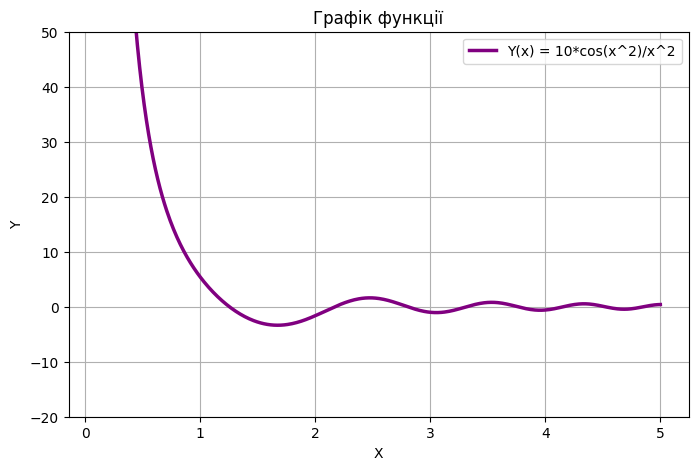

In [33]:
x = np.linspace(0.1, 5, 500)
y = 10 * np.cos(x**2) / (x**2)

plt.figure(figsize=(8, 5))
plt.plot(x, y, linestyle='-', color='purple', linewidth=2.5, label='Y(x) = 10*cos(x^2)/x^2')

plt.ylim(-20, 50)

plt.title('Графік функції')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.grid(True)
plt.show()

# Завдання 2

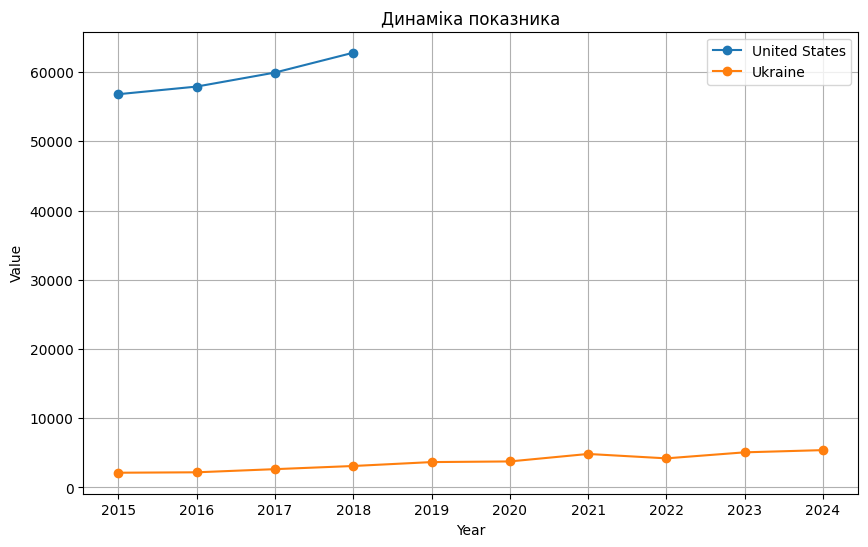

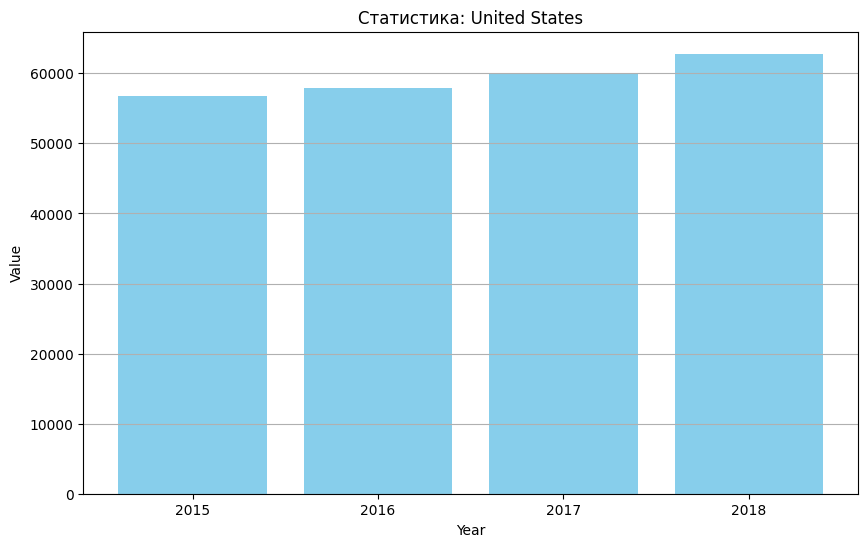

In [41]:
import csv

years = []
year_indices = []
data = {}

with open('data.csv', 'r', encoding='utf-8') as f:
    reader = csv.reader(f)
    header = next(reader)
    
    for i, col in enumerate(header):
        if '[YR' in col:
            years.append(int(col.split('[')[0].strip()))
            year_indices.append(i)
            
    for row in reader:
        if not row or not row[0].strip():
            continue
        if row[0].startswith('Data from') or row[0] == 'Code':
            break
            
        country = row[0]
        values = []
        for i in year_indices:
            val = row[i]
            if val == '..':
                values.append(None)
            else:
                values.append(float(val))
        data[country] = values

plt.figure(figsize=(10, 6))
all_years_plotted = set()

for country, values in data.items():
    clean_data = sorted([(y, v) for y, v in zip(years, values) if v is not None])
    if not clean_data:
        continue
        
    c_years = [item[0] for item in clean_data]
    c_vals = [item[1] for item in clean_data]
    all_years_plotted.update(c_years)
    
    plt.plot(c_years, c_vals, label=country, marker='o')

plt.xticks(sorted(list(all_years_plotted)))
plt.title('Динаміка показника')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

country_input = input("Введіть назву країни: ")

if country_input in data:
    clean_data = sorted([(y, v) for y, v in zip(years, data[country_input]) if v is not None])
    if clean_data:
        c_years = [item[0] for item in clean_data]
        c_vals = [item[1] for item in clean_data]
        
        plt.figure(figsize=(10, 6))
        plt.bar(c_years, c_vals, color='skyblue')
        plt.xticks(c_years)
        plt.title(f'Статистика: {country_input}')
        plt.xlabel('Year')
        plt.ylabel('Value')
        plt.grid(axis='y')
        plt.show()
    else:
        print("Немає даних для побудови.")
else:
    print("Невірна назва країни.")

# Завдання 3

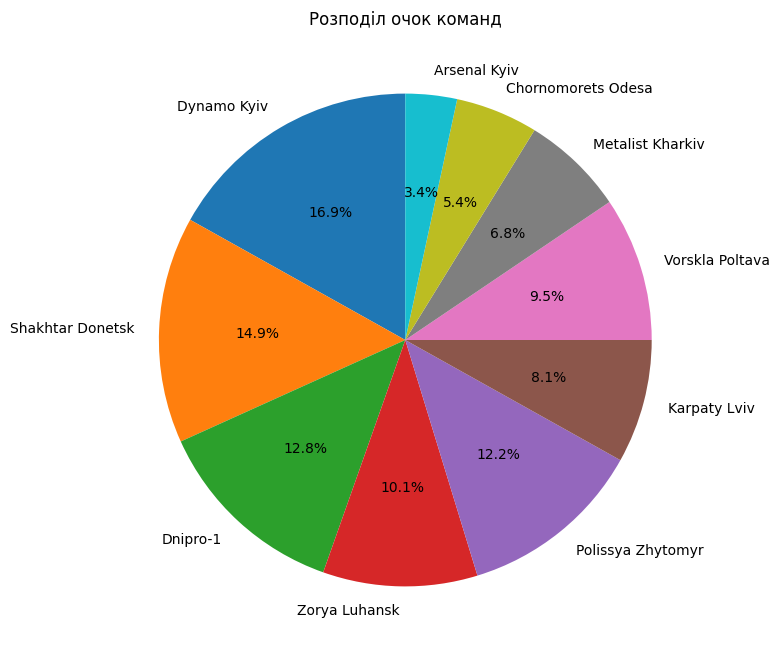

In [ ]:
with open('../Практична робота №9/teams.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

labels = [team['Name'] for team in data]
values = [team['Points'] for team in data]

plt.figure(figsize=(10, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title('Розподіл очок команд')
plt.show()